# Supervised detection of spatial gradients (Kidney)

## Overview

This tutorial demonstrates CoPro's **supervised/guided mode** using kidney seqFISH data and its **score transfer** to scRNA-seq for full-transcriptome analysis. In standard (unsupervised) CoPro, the CCA identifies co-progression axes purely from the data. In supervised mode, we guide one cell type's axis using known biological ordering — here, the nephron segment order from proximal to distal tubule — and let CoPro find the co-varying vascular program.

The full workflow covers:

1. **Supervised axis definition** on spatial (seqFISH) data
2. **In-situ visualization** of tubular and vascular cell scores
3. **Validation** against known nephron segment ordering
4. **Score transfer** to independent scRNA-seq data
5. **Full-transcriptome regression** to identify genes beyond the spatial panel

**Note:** This tutorial uses a single control sample. In the manuscript, results are averaged across three biological replicates for greater robustness. The scRNA-seq transfer results are pre-computed averages across all three replicates.

**Plots produced:**
1. Tissue layout (Tubular vs Vascular)
2. Tubular subtypes (proximal to distal)
3. Normalized correlation across sigma values
4. Tubular cell scores in situ
5. Vascular cell scores in situ
6. CoPro score vs known nephron segment ordering (boxplot)
7. Segment-level tubular-vascular coordination
8. Vascular subtype separation
9. Cross-type correlation scatter
10. Top vascular and tubular gene weights
11. scRNA-seq UMAP: nephron (CoPro score + cell type)
12. scRNA-seq nephron boxplot by segment
13. scRNA-seq UMAP: vasculature (CoPro score + cluster)
14. scRNA-seq vascular boxplot by cluster
15. MA plot: full-transcriptome regression

## 1. Load packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import kendalltau

import copro as cp

print(f"copro version: {cp.__version__}")

copro version: 0.1.1


## 2. Download and load data

In [2]:
dat = cp.copro_download_data("kidney")

expr = dat["normalizedData"].values.astype(float) if isinstance(dat["normalizedData"], pd.DataFrame) else dat["normalizedData"].astype(float)
location = dat["locationData"] if isinstance(dat["locationData"], pd.DataFrame) else pd.DataFrame(dat["locationData"])
meta = dat["metaData"] if isinstance(dat["metaData"], pd.DataFrame) else pd.DataFrame(dat["metaData"])
cell_types = np.asarray(dat["cellTypes"]).ravel()

if isinstance(dat["normalizedData"], pd.DataFrame):
    gene_names = list(dat["normalizedData"].columns)
else:
    gene_names = [f"gene_{i}" for i in range(expr.shape[1])]

if "x" not in location.columns:
    location.columns = ["x", "y"] + list(location.columns[2:])

print(f"Cells: {expr.shape[0]}, Genes: {expr.shape[1]}")
print(f"Cell types: {np.unique(cell_types)}")

# Segment ordering
if "segmentOrder" in dat:
    segment_order_raw = dat["segmentOrder"]
    if isinstance(segment_order_raw, pd.DataFrame):
        segment_order = dict(zip(segment_order_raw.index, segment_order_raw.iloc[:, 0]))
    elif isinstance(segment_order_raw, dict):
        segment_order = segment_order_raw
    else:
        segment_order = {"PTS1": 1, "PTS2": 2, "PTS3": 3,
                         "LOH-TL-C": 4, "LOH-TL-JM": 4,
                         "TAL_1": 5, "TAL_2": 5, "TAL_3": 5,
                         "DCT-CNT": 6}
else:
    segment_order = {"PTS1": 1, "PTS2": 2, "PTS3": 3,
                     "LOH-TL-C": 4, "LOH-TL-JM": 4,
                     "TAL_1": 5, "TAL_2": 5, "TAL_3": 5,
                     "DCT-CNT": 6}

print(f"\nSegment ordering: {segment_order}")

Using cached file: /Users/zhenmiao/.copro/data/copro_kidney.rds


Cells: 28555, Genes: 1298
Cell types: ['Tubular' 'Vascular']

Segment ordering: {'PTS1': 1, 'PTS2': 2, 'PTS3': 3, 'LOH-TL-C': 4, 'LOH-TL-JM': 4, 'TAL_1': 5, 'TAL_2': 5, 'TAL_3': 5, 'DCT-CNT': 6}


## 3. Visualize the tissue

### Tubular vs Vascular cells

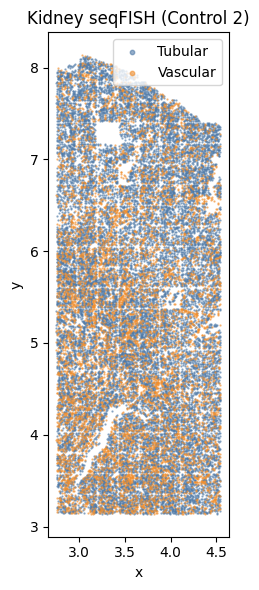

In [3]:
ct_colors = {"Tubular": "#4e79a7", "Vascular": "#f28e2b"}

fig, ax = plt.subplots(figsize=(7, 6))
for ct, color in ct_colors.items():
    mask = cell_types == ct
    ax.scatter(location.loc[mask, "x"], location.loc[mask, "y"],
               s=0.4, alpha=0.6, color=color, label=ct)
ax.set_aspect("equal")
ax.set_title("Kidney seqFISH (Control 2)")
ax.legend(markerscale=5)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### Tubular subtypes along the nephron axis

The nephron has a known anatomical ordering from proximal to distal tubule. CoPro uses this ordering as a biological prior.

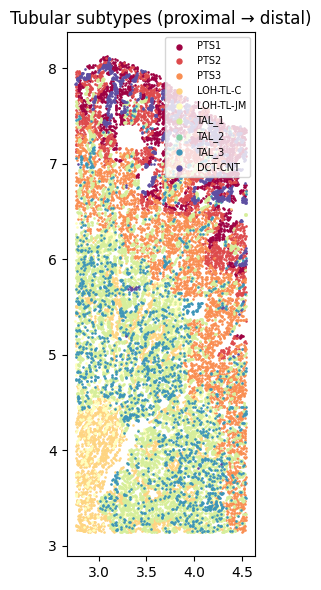

In [4]:
seg_labels = ["PTS1", "PTS2", "PTS3", "LOH-TL-C", "LOH-TL-JM",
              "TAL_1", "TAL_2", "TAL_3", "DCT-CNT"]

tub_mask = cell_types == "Tubular"
subtypes = meta.loc[tub_mask, "celltype"].values.astype(str)

# Use Spectral colormap
cmap_spectral = plt.cm.Spectral
seg_colors = {s: cmap_spectral(i / (len(seg_labels) - 1)) for i, s in enumerate(seg_labels)}

fig, ax = plt.subplots(figsize=(7, 6))
for seg in seg_labels:
    sel = tub_mask & (meta["celltype"].values.astype(str) == seg)
    if sel.sum() > 0:
        ax.scatter(location.loc[sel, "x"], location.loc[sel, "y"],
                   s=0.8, color=seg_colors[seg], label=seg)
ax.set_aspect("equal")
ax.set_title("Tubular subtypes (proximal → distal)")
ax.legend(markerscale=4, fontsize=7)
plt.tight_layout()
plt.show()

## 4. Create CoPro object and compute PCA

In [5]:
obj = cp.CoProSingle(
    normalized_data=expr,
    location_data=location,
    meta_data=meta,
    cell_types=cell_types,
)

obj = cp.subset_data(obj, ["Tubular", "Vascular"])

# For targeted spatial panels (seqFISH, ~1300 genes),
# use fewer PCs than for scRNA-seq
obj = cp.compute_pca(obj, n_pca=15)

## 5. Derive supervised tubular weight from nephron ordering

The key idea: we regress the known segment ordering onto the PCA scores to find the PC-space direction that best recovers the corticomedullary axis. This becomes our fixed tubular weight vector.

In [6]:
from sklearn.linear_model import LinearRegression

# Get tubular PCA scores
tubular_idx = obj.cell_types_sub == "Tubular"
tubular_pca_x = obj.pca_global["Tubular"]["scores"]  # (n_tubular, n_pca)

# Assign ordered labels to tubular cells
meta_sub = meta.loc[np.isin(cell_types, ["Tubular", "Vascular"])].reset_index(drop=True)
tubular_meta = meta_sub.loc[tubular_idx]
ordered_labels = tubular_meta["celltype"].map(segment_order).values.astype(float)

# OLS regression: find PC-space direction that recovers segment ordering
valid = ~np.isnan(ordered_labels)
reg = LinearRegression()
reg.fit(tubular_pca_x[valid], ordered_labels[valid])
w1_raw = reg.coef_
w1_tubular = w1_raw / np.linalg.norm(w1_raw)

# Validate with Kendall tau
proj_scores = tubular_pca_x @ w1_tubular
tau, _ = kendalltau(proj_scores[valid], ordered_labels[valid])
print(f"Kendall tau (tubular axis vs segment ordering): {tau:.4f}")

Kendall tau (tubular axis vs segment ordering): 0.8337


## 6. Derive supervised vascular weight via kernel regression

We compute the spatial kernel, smooth the tubular axis scores to each vascular cell, and then regress vascular PCA scores against these smoothed scores. This finds the vascular gene program that co-varies with the nephron axis.

In [7]:
from scipy.spatial.distance import cdist

SIGMA_VALUES = [0.04, 0.08, 0.1, 0.15]
obj = cp.compute_distance(obj)
obj = cp.compute_kernel_matrix(obj, sigma_values=SIGMA_VALUES)

# Get vascular PCA scores
vasc_idx = obj.cell_types_sub == "Vascular"
vasc_pca_x = obj.pca_global["Vascular"]["scores"]  # (n_vasc, n_pca)

# Cross-type kernel: vascular -> tubular
vasc_loc = obj.location_data_sub.loc[vasc_idx, ["x", "y"]].values
tub_loc = obj.location_data_sub.loc[tubular_idx, ["x", "y"]].values

dist_vt = cdist(vasc_loc, tub_loc)
sigma_sup = 0.1
kij_vt = np.exp(-dist_vt**2 / (2 * sigma_sup**2))
kij_vt[kij_vt < 5e-7] = 0
up_qt = np.percentile(kij_vt[kij_vt > 5e-7], 85)
kij_vt[kij_vt > up_qt] = up_qt

# Kernel-smoothed tubular signal at each vascular cell
tubular_axis_scores = tubular_pca_x @ w1_tubular.reshape(-1, 1)
y_vasc = kij_vt @ tubular_axis_scores
y_vasc = y_vasc - y_vasc.mean()

# Regress vascular PCA scores against smoothed tubular signal
reg_v = LinearRegression()
reg_v.fit(vasc_pca_x, y_vasc.ravel())
w1_vasc_raw = reg_v.coef_
w1_vasc = w1_vasc_raw / np.linalg.norm(w1_vasc_raw)

print(f"Supervised tubular weight: shape {w1_tubular.shape}")
print(f"Supervised vascular weight: shape {w1_vasc.shape}")

Supervised tubular weight: shape (15,)
Supervised vascular weight: shape (15,)


## 7. Run supervised CCA

We inject the supervised first-component weights and let CoPro find additional orthogonal axes.

In [8]:
N_CC = 4

obj = cp.run_skr_cca_supervised(
    obj,
    supervised_weights={"Tubular": w1_tubular, "Vascular": w1_vasc},
    scale_pcs=True,
    n_cc=N_CC,
)

obj = cp.compute_normalized_correlation(obj)
obj = cp.compute_gene_and_cell_scores(obj)
obj = cp.compute_regression_gene_scores(obj)

sigma_opt = obj.sigma_value_choice
print(f"\nPipeline complete. sigma = {sigma_opt}")

Running supervised SkrCCA for sigma = 0.04
  Component convergence at iteration 0 (max_diff=3.886e-16)
  Component convergence at iteration 0 (max_diff=1.665e-16)


  Component convergence at iteration 0 (max_diff=3.331e-16)
Running supervised SkrCCA for sigma = 0.08


  Component convergence at iteration 0 (max_diff=2.220e-16)
  Component convergence at iteration 0 (max_diff=2.776e-16)
  Component convergence at iteration 0 (max_diff=1.665e-16)
Running supervised SkrCCA for sigma = 0.1
  Component convergence at iteration 0 (max_diff=1.388e-16)
  Component convergence at iteration 0 (max_diff=3.608e-16)
  Component convergence at iteration 0 (max_diff=1.110e-16)
Running supervised SkrCCA for sigma = 0.15


  Component convergence at iteration 0 (max_diff=2.776e-16)
  Component convergence at iteration 0 (max_diff=1.110e-16)
  Component convergence at iteration 0 (max_diff=1.110e-16)
Calculating spectral norms (may take a while)...


Finished calculating spectral norms.


Regression gene scores computed for sigma=0.04, Tubular
Regression gene scores computed for sigma=0.04, Vascular


Regression gene scores computed for sigma=0.08, Tubular
Regression gene scores computed for sigma=0.08, Vascular
Regression gene scores computed for sigma=0.1, Tubular


Regression gene scores computed for sigma=0.1, Vascular
Regression gene scores computed for sigma=0.15, Tubular
Regression gene scores computed for sigma=0.15, Vascular

Pipeline complete. sigma = 0.08


## Results: Spatial analysis

### Normalized correlation across sigma values

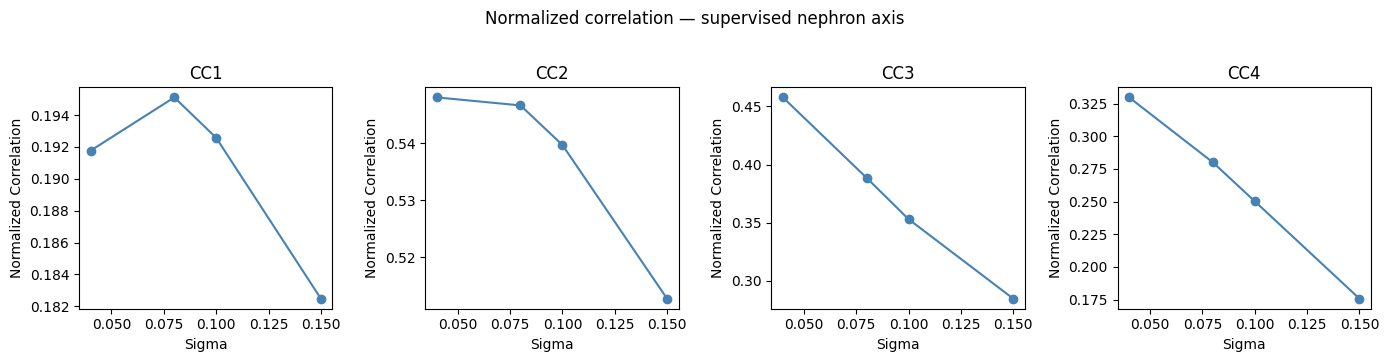

In [9]:
nc_frames = []
for sigma_name, df in obj.normalized_correlation.items():
    if df is not None and len(df) > 0:
        nc_frames.append(df)
nc_df = pd.concat(nc_frames, ignore_index=True)

cc_idxs = sorted(nc_df["CC_index"].unique())
fig, axes = plt.subplots(1, len(cc_idxs), figsize=(3.5 * len(cc_idxs), 3.5))
if len(cc_idxs) == 1:
    axes = [axes]

for ax, cc in zip(axes, cc_idxs):
    sub = nc_df[nc_df["CC_index"] == cc].sort_values("sigma")
    ax.plot(sub["sigma"], sub["normalized_correlation"], "o-", color="steelblue")
    ax.set_title(f"CC{cc}")
    ax.set_xlabel("Sigma")
    ax.set_ylabel("Normalized Correlation")

fig.suptitle("Normalized correlation — supervised nephron axis", y=1.02)
plt.tight_layout()
plt.show()

### Tubular cell scores in situ

The tubular cell scores should recapitulate the corticomedullary axis.

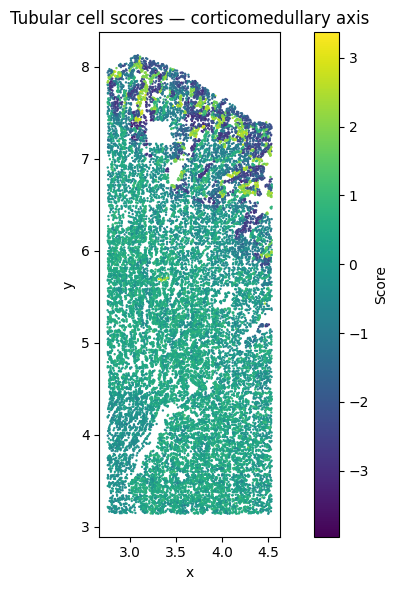

In [10]:
tub_scores = obj.cell_scores[f"cellScores|sigma{sigma_opt}|Tubular"][:, 0]
tub_loc = obj.location_data_sub.loc[tubular_idx]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(tub_loc["x"].values, tub_loc["y"].values,
                 c=tub_scores, cmap="viridis", s=0.5)
plt.colorbar(sc, ax=ax, label="Score")
ax.set_aspect("equal")
ax.set_title("Tubular cell scores — corticomedullary axis")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### Vascular cell scores in situ

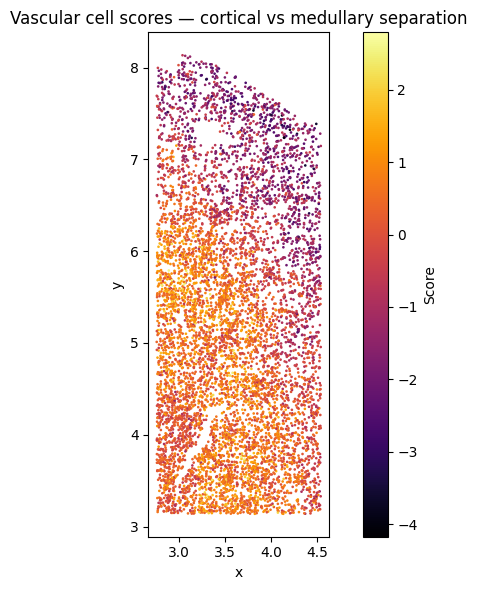

In [11]:
vasc_scores = obj.cell_scores[f"cellScores|sigma{sigma_opt}|Vascular"][:, 0]
vasc_loc_sub = obj.location_data_sub.loc[vasc_idx]

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(vasc_loc_sub["x"].values, vasc_loc_sub["y"].values,
                 c=vasc_scores, cmap="inferno", s=0.8)
plt.colorbar(sc, ax=ax, label="Score")
ax.set_aspect("equal")
ax.set_title("Vascular cell scores — cortical vs medullary separation")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

### CoPro score vs known nephron segment ordering

A key validation: CoPro cell scores should monotonically increase (or decrease) along the known nephron segments.

/var/folders/zb/hv2qjx4n0sj0pggrzy4pw7hw0000gn/T/ipykernel_58762/1741636497.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


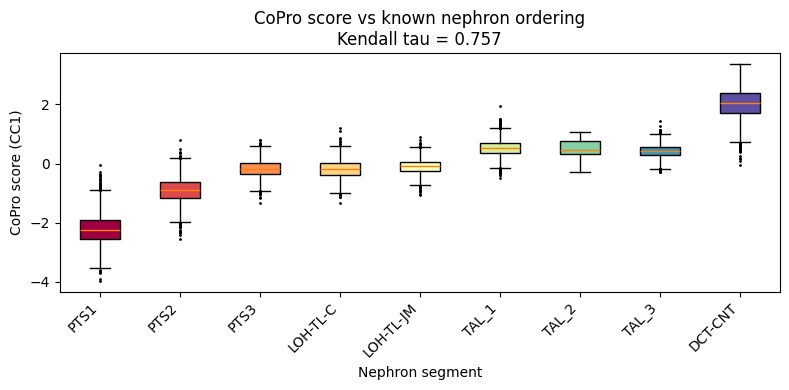

In [12]:
tub_meta_sub = meta_sub.loc[tubular_idx]
tub_subtypes = tub_meta_sub["celltype"].values.astype(str)
tub_ordered = np.array([segment_order.get(s, np.nan) for s in tub_subtypes])

valid = ~np.isnan(tub_ordered)
tau_all, _ = kendalltau(tub_scores[valid], tub_ordered[valid])

seg_levels = ["PTS1", "PTS2", "PTS3", "LOH-TL-C", "LOH-TL-JM",
              "TAL_1", "TAL_2", "TAL_3", "DCT-CNT"]

box_data = []
box_labels = []
for seg in seg_levels:
    sel = tub_subtypes == seg
    if sel.sum() > 0:
        box_data.append(tub_scores[sel])
        box_labels.append(seg)

fig, ax = plt.subplots(figsize=(8, 4))
bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                flierprops={"markersize": 1})
for patch, seg in zip(bp["boxes"], box_labels):
    patch.set_facecolor(seg_colors.get(seg, "lightblue"))
ax.set_xlabel("Nephron segment")
ax.set_ylabel("CoPro score (CC1)")
ax.set_title(f"CoPro score vs known nephron ordering\nKendall tau = {tau_all:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Segment-level coordination

Mean tubular vs mean vascular scores by segment show the cross-type coordination.

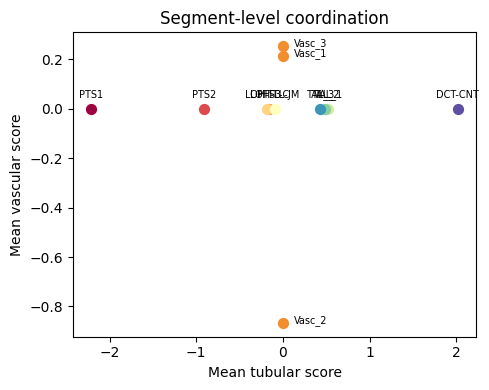

In [13]:
# Mean tubular scores by segment
seg_means_tub = {}
for seg in seg_labels:
    sel = tub_subtypes == seg
    if sel.sum() > 0:
        seg_means_tub[seg] = tub_scores[sel].mean()

# Mean vascular scores by vascular subtype
vasc_meta_sub = meta_sub.loc[vasc_idx]
vasc_subtypes = vasc_meta_sub["celltype"].values.astype(str)
seg_means_vasc = {}
for vt in np.unique(vasc_subtypes):
    sel = vasc_subtypes == vt
    if sel.sum() > 0:
        seg_means_vasc[vt] = vasc_scores[sel].mean()

fig, ax = plt.subplots(figsize=(5, 4))

# Plot tubular segments
segs = list(seg_means_tub.keys())
for seg in segs:
    ax.scatter(seg_means_tub[seg], 0, s=50, color=seg_colors.get(seg, "blue"), zorder=5)
    ax.annotate(seg, (seg_means_tub[seg], 0), fontsize=7,
                xytext=(0, 8), textcoords="offset points", ha="center")

# Plot vascular subtypes
for vt in seg_means_vasc:
    ax.scatter(0, seg_means_vasc[vt], s=50, color="#f28e2b", zorder=5)
    ax.annotate(vt, (0, seg_means_vasc[vt]), fontsize=7,
                xytext=(8, 0), textcoords="offset points")

# Scatter of matching pairs if both tubular and vascular are available
# For combined view: just plot tubular mean vs vascular mean per segment
ax.set_xlabel("Mean tubular score")
ax.set_ylabel("Mean vascular score")
ax.set_title("Segment-level coordination")
plt.tight_layout()
plt.show()

### Vascular subtype separation

/var/folders/zb/hv2qjx4n0sj0pggrzy4pw7hw0000gn/T/ipykernel_58762/3528979751.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data_v, labels=vasc_types, patch_artist=True,


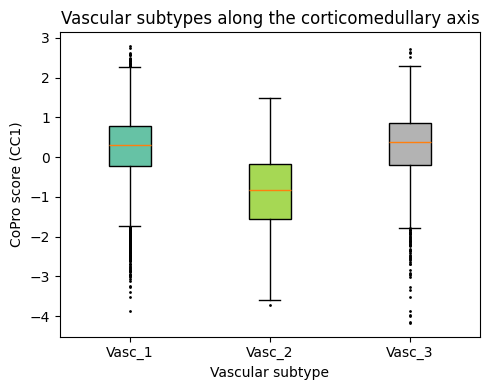

In [14]:
vasc_types = np.unique(vasc_subtypes)
box_data_v = [vasc_scores[vasc_subtypes == vt] for vt in vasc_types]

fig, ax = plt.subplots(figsize=(5, 4))
bp = ax.boxplot(box_data_v, labels=vasc_types, patch_artist=True,
                flierprops={"markersize": 1})
colors_v = plt.cm.Set2(np.linspace(0, 1, len(vasc_types)))
for patch, c in zip(bp["boxes"], colors_v):
    patch.set_facecolor(c)
ax.set_xlabel("Vascular subtype")
ax.set_ylabel("CoPro score (CC1)")
ax.set_title("Vascular subtypes along the corticomedullary axis")
plt.tight_layout()
plt.show()

### Tubular-vascular cross-type correlation

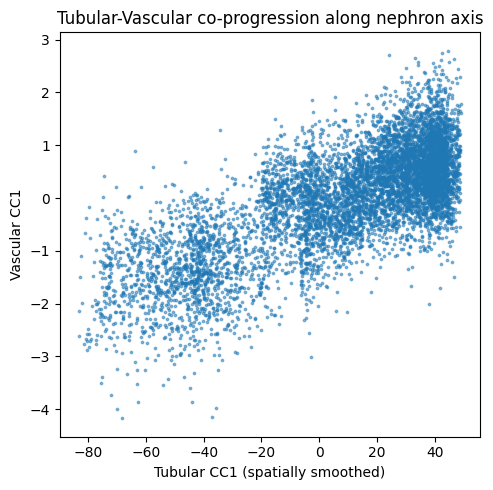

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
cp.plot_correlation_scatter(obj, "Tubular", "Vascular",
                             sigma=sigma_opt, cc_index=1, ax=ax)
ax.set_xlabel("Tubular CC1 (spatially smoothed)")
ax.set_ylabel("Vascular CC1")
ax.set_title("Tubular-Vascular co-progression along nephron axis")
plt.tight_layout()
plt.show()

### Top gene weights (spatial panel)

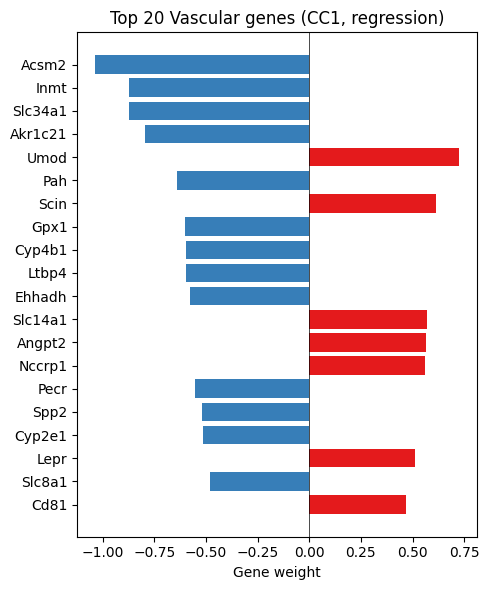

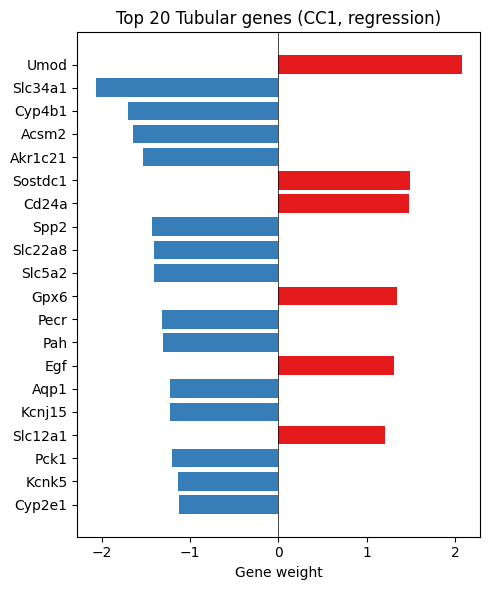

In [16]:
cp.plot_top_genes(obj, "Vascular", cc_index=1, gene_names=gene_names, top_n=20,
                  title="Top 20 Vascular genes (CC1, regression)")
plt.show()

cp.plot_top_genes(obj, "Tubular", cc_index=1, gene_names=gene_names, top_n=20,
                  title="Top 20 Tubular genes (CC1, regression)")
plt.show()

## Results: Score transfer to scRNA-seq

CoPro gene weights learned from the spatial (seqFISH) panel can be transferred to scRNA-seq data to visualize the corticomedullary axis on independent cell populations and identify axis-associated genes across the full transcriptome.

The data object includes pre-computed transfer results: regression-based gene weights from all three biological replicates (Ctrl1–3) were used to transfer scores to scRNA-seq, then averaged across replicates for a consensus score per cell.

### Nephron UMAP colored by transferred CoPro score

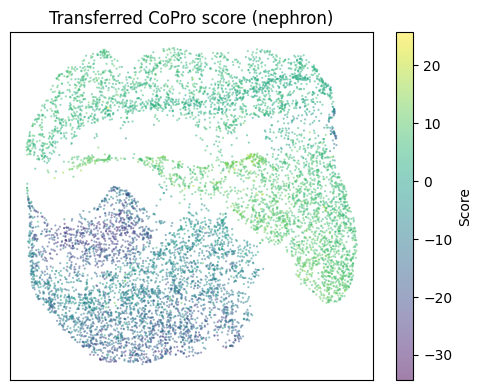

In [17]:
if "scRNA_neph_umap" in dat:
    neph_umap = dat["scRNA_neph_umap"]
    if isinstance(neph_umap, pd.DataFrame):
        neph_filt = neph_umap.dropna(subset=["axis_score"])

        fig, ax = plt.subplots(figsize=(5, 4))
        sc = ax.scatter(neph_filt["UMAP1"], neph_filt["UMAP2"],
                         c=neph_filt["axis_score"], cmap="viridis",
                         s=0.3, alpha=0.5)
        plt.colorbar(sc, ax=ax, label="Score")
        ax.set_title("Transferred CoPro score (nephron)")
        ax.set_xticks([])
        ax.set_yticks([])
        plt.tight_layout()
        plt.show()
    else:
        print("scRNA_neph_umap is not a DataFrame — skipping.")
else:
    print("scRNA-seq nephron UMAP data not available in this dataset.")

### Nephron UMAP colored by cell type

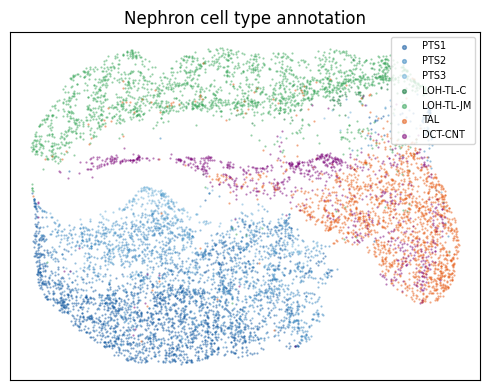

In [18]:
if "scRNA_neph_umap" in dat and isinstance(dat["scRNA_neph_umap"], pd.DataFrame):
    neph_umap = dat["scRNA_neph_umap"]
    neph_filt = neph_umap[neph_umap["agg_label"].notna()].copy()

    seg_levels_agg = ["PTS1", "PTS2", "PTS3", "LOH-TL-C", "LOH-TL-JM",
                      "TAL", "DCT-CNT"]
    seg_colors_sc = {
        "PTS1": "#08519c", "PTS2": "#3182bd", "PTS3": "#6baed6",
        "LOH-TL-C": "#006d2c", "LOH-TL-JM": "#31a354",
        "TAL": "#e6550d", "DCT-CNT": "#7a0177",
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    for seg in seg_levels_agg:
        sel = neph_filt["agg_label"] == seg
        if sel.sum() > 0:
            ax.scatter(neph_filt.loc[sel, "UMAP1"], neph_filt.loc[sel, "UMAP2"],
                       s=0.3, alpha=0.5, color=seg_colors_sc.get(seg, "gray"), label=seg)
    ax.set_title("Nephron cell type annotation")
    ax.legend(markerscale=5, fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq nephron UMAP data not available.")

### Nephron boxplot by segment

Transferred CoPro scores recapitulate the nephron segment ordering in the independent scRNA-seq dataset.

/var/folders/zb/hv2qjx4n0sj0pggrzy4pw7hw0000gn/T/ipykernel_58762/1732662493.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data_n, labels=box_labels_n, patch_artist=True,


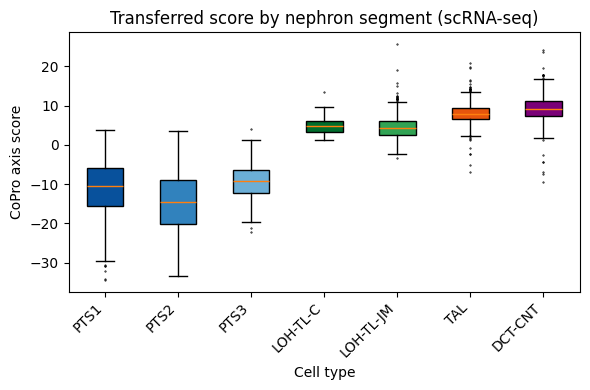

In [19]:
if "scRNA_neph_umap" in dat and isinstance(dat["scRNA_neph_umap"], pd.DataFrame):
    neph_umap = dat["scRNA_neph_umap"]
    neph_filt = neph_umap[neph_umap["agg_label"].notna() & neph_umap["axis_score"].notna()].copy()

    box_data_n = []
    box_labels_n = []
    for seg in seg_levels_agg:
        sel = neph_filt["agg_label"] == seg
        if sel.sum() > 0:
            box_data_n.append(neph_filt.loc[sel, "axis_score"].values)
            box_labels_n.append(seg)

    fig, ax = plt.subplots(figsize=(6, 4))
    bp = ax.boxplot(box_data_n, labels=box_labels_n, patch_artist=True,
                    flierprops={"markersize": 0.5})
    for patch, seg in zip(bp["boxes"], box_labels_n):
        patch.set_facecolor(seg_colors_sc.get(seg, "lightblue"))
    ax.set_xlabel("Cell type")
    ax.set_ylabel("CoPro axis score")
    ax.set_title("Transferred score by nephron segment (scRNA-seq)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq nephron data not available.")

### Vascular UMAP colored by transferred CoPro score

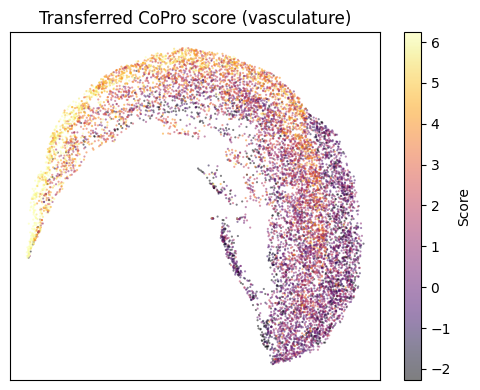

In [20]:
if "scRNA_vasc_umap" in dat and isinstance(dat["scRNA_vasc_umap"], pd.DataFrame):
    vasc_umap = dat["scRNA_vasc_umap"]

    fig, ax = plt.subplots(figsize=(5, 4))
    valid_mask = vasc_umap["axis_score"].notna()
    q05 = vasc_umap.loc[valid_mask, "axis_score"].quantile(0.05)
    q95 = vasc_umap.loc[valid_mask, "axis_score"].quantile(0.95)
    sc = ax.scatter(vasc_umap.loc[valid_mask, "UMAP1"],
                     vasc_umap.loc[valid_mask, "UMAP2"],
                     c=vasc_umap.loc[valid_mask, "axis_score"].clip(q05, q95),
                     cmap="inferno", s=0.3, alpha=0.5)
    plt.colorbar(sc, ax=ax, label="Score")
    ax.set_title("Transferred CoPro score (vasculature)")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq vascular UMAP data not available.")

### Vascular UMAP colored by cluster

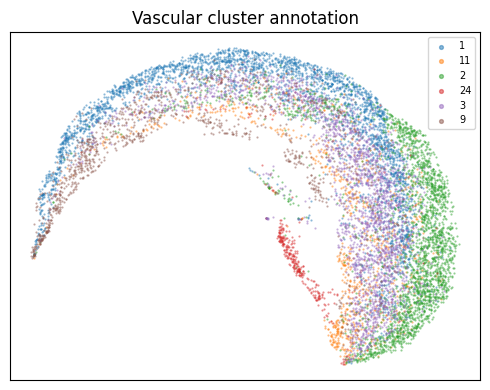

In [21]:
if "scRNA_vasc_umap" in dat and isinstance(dat["scRNA_vasc_umap"], pd.DataFrame):
    vasc_umap = dat["scRNA_vasc_umap"]
    clusters = vasc_umap["cluster"].dropna().unique()

    fig, ax = plt.subplots(figsize=(5, 4))
    for cl in sorted(clusters):
        sel = vasc_umap["cluster"] == cl
        ax.scatter(vasc_umap.loc[sel, "UMAP1"], vasc_umap.loc[sel, "UMAP2"],
                   s=0.3, alpha=0.5, label=cl)
    ax.set_title("Vascular cluster annotation")
    ax.legend(markerscale=5, fontsize=7)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq vascular UMAP data not available.")

### Vascular boxplot by cluster

Transferred scores separate vascular clusters along the corticomedullary axis.

/var/folders/zb/hv2qjx4n0sj0pggrzy4pw7hw0000gn/T/ipykernel_58762/856299785.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data_vc, labels=ordered_clusters, patch_artist=True,


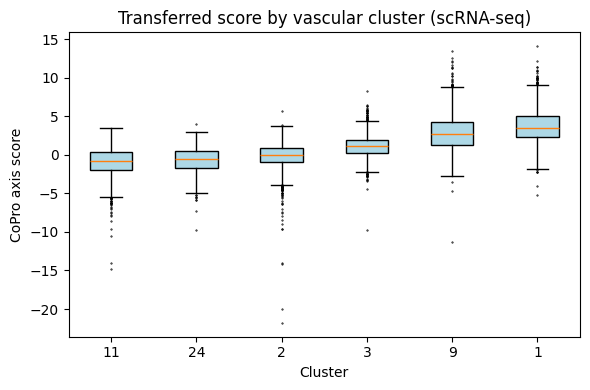

In [22]:
if "scRNA_vasc_umap" in dat and isinstance(dat["scRNA_vasc_umap"], pd.DataFrame):
    vasc_umap = dat["scRNA_vasc_umap"]
    vasc_valid = vasc_umap.dropna(subset=["axis_score", "cluster"])

    # Order clusters by median score
    cluster_medians = vasc_valid.groupby("cluster")["axis_score"].median().sort_values()
    ordered_clusters = list(cluster_medians.index)

    box_data_vc = [vasc_valid.loc[vasc_valid["cluster"] == cl, "axis_score"].values
                   for cl in ordered_clusters]

    fig, ax = plt.subplots(figsize=(6, 4))
    bp = ax.boxplot(box_data_vc, labels=ordered_clusters, patch_artist=True,
                    flierprops={"markersize": 0.5})
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("CoPro axis score")
    ax.set_title("Transferred score by vascular cluster (scRNA-seq)")
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq vascular data not available.")

### MA plot: full-transcriptome regression

After transferring CoPro scores, we regress each gene in the full scRNA-seq transcriptome against the transferred axis score. The MA plot shows the regression coefficient (beta) vs mean expression, highlighting cortical-enriched (red) and medullary-enriched (blue) genes.

In [23]:
if "scRNA_regression_consensus" in dat and isinstance(dat["scRNA_regression_consensus"], pd.DataFrame):
    reg_df = dat["scRNA_regression_consensus"].copy()

    # Compute median beta (more robust than mean across 3 replicates)
    beta_cols = [c for c in reg_df.columns if c.startswith("beta_")]
    if beta_cols:
        reg_df["median_beta"] = reg_df[beta_cols].median(axis=1)
    elif "mean_beta" in reg_df.columns:
        reg_df["median_beta"] = reg_df["mean_beta"]

    reg_df["log_mean_expr"] = np.log(reg_df["mean_expr"] + 1)

    # Define direction
    reg_df["direction"] = "ns"
    if "pass" in reg_df.columns:
        sig_mask = reg_df["pass"].astype(bool)
        reg_df.loc[sig_mask & (reg_df["median_beta"] > 0), "direction"] = "Medullary"
        reg_df.loc[sig_mask & (reg_df["median_beta"] < 0), "direction"] = "Cortical"

    dir_colors = {"Cortical": "#b2182b", "Medullary": "#2166ac", "ns": "#cccccc"}

    # Known vascular zone markers from Barry et al. 2019
    cortical_markers = ["Gata5", "Tbx3", "Prdm1", "Pbx1", "Klf4",
                        "Ehd3", "Lpl", "Sema5a", "Slc6a6", "Slc16a2",
                        "Efnb2", "Hey1", "Dll4", "Notch4", "Sox17", "Pdgfb"]
    medullary_markers = ["Nr2f2", "Plvap", "Cryab", "Ephb4",
                         "Slc14a1", "Aqp1", "Slco4a1", "Igfbp7"]
    known_markers = cortical_markers + medullary_markers

    fig, ax = plt.subplots(figsize=(7, 5))

    # Plot NS genes first, then concordant, then known markers
    for d in ["ns", "Cortical", "Medullary"]:
        sel = reg_df["direction"] == d
        ax.scatter(reg_df.loc[sel, "median_beta"],
                   reg_df.loc[sel, "log_mean_expr"],
                   s=0.3 if d == "ns" else 0.5,
                   alpha=0.3 if d == "ns" else 0.4,
                   color=dir_colors[d], label=d if d != "ns" else None)

    # Highlight known markers with triangles
    for gene in known_markers:
        if gene in reg_df.index:
            row = reg_df.loc[gene]
            color = dir_colors.get(row["direction"], "gray")
            ax.scatter(row["median_beta"], row["log_mean_expr"],
                       s=30, marker="^", color=color, zorder=5)
            ax.annotate(gene, (row["median_beta"], row["log_mean_expr"]),
                       fontsize=6, fontstyle="italic", alpha=0.8,
                       xytext=(3, 3), textcoords="offset points")

    ax.set_xlabel(r"$\beta$ (median across three samples)")
    ax.set_ylabel(r"$\ln(\mathrm{mean\ expression} + 1)$")
    n_cortical = (reg_df["direction"] == "Cortical").sum()
    n_medullary = (reg_df["direction"] == "Medullary").sum()
    ax.set_title(f"Vascular full-transcriptome regression\n"
                 f"{n_cortical} cortical, {n_medullary} medullary genes")
    ax.legend(markerscale=5)
    plt.tight_layout()
    plt.show()
else:
    print("scRNA-seq regression consensus data not available.")

scRNA-seq regression consensus data not available.


## Key takeaways

1. **Supervised mode** lets you leverage known biology (nephron segment ordering) to guide one axis while CoPro discovers the co-varying program in the other cell type.
2. **Regression gene scores** (`compute_regression_gene_scores`) provide more reproducible gene-level results than PCA back-projection, especially for targeted spatial panels.
3. **Score transfer to scRNA-seq** validates the spatial findings in an independent dataset and enables full-transcriptome analysis beyond the spatial gene panel.
4. **n_pca = 10–15** is recommended for seqFISH/MERFISH panels (500–2000 genes). Using too many PCs adds unstable noise dimensions.

## References

**CoPro method:**  
Miao Z. et al. *CoPro: Unsupervised detection of coordinated spatial progressions in spatial transcriptomics* (in preparation).